# Part 1: Probability Distribution 

In [6]:
import numpy as np
import pandas as pd

**Loading the data**

In [7]:
df = pd.read_csv("GaltonFamilies.csv")

print(df.head())

   rownames family  father  mother  midparentHeight  children  childNum  \
0         1    001    78.5    67.0            75.43         4         1   
1         2    001    78.5    67.0            75.43         4         2   
2         3    001    78.5    67.0            75.43         4         3   
3         4    001    78.5    67.0            75.43         4         4   
4         5    002    75.5    66.5            73.66         4         1   

   gender  childHeight  
0    male         73.2  
1  female         69.2  
2  female         69.0  
3  female         69.0  
4    male         73.5  


In [8]:
father_heights = df["father"].values
child_heights = df["childHeight"].values

heights = np.concatenate([father_heights, child_heights])
heights

array([78.5, 78.5, 78.5, ..., 61. , 66.5, 57. ], shape=(1868,))

**Initializing the parameters**

In [9]:
# mean
mu1 = np.percentile(heights, 25)
mu2 = np.percentile(heights, 75)
# variance
sigma1 = np.var(heights)
sigma2 = np.var(heights)
# coeffieciency Imagine it is 50 50
pi1 = 0.5
pi2 = 0.5


**Gaussian Function**

In [10]:
def gaussian(x, mu, sigma):
    return (
        1 / np.sqrt(2 * np.pi * sigma)
    ) * np.exp(
        -((x - mu) ** 2) / (2 * sigma)
    )

#Testing the gaussian
print(gaussian(70, 70, 4))
print(gaussian(90, 70, 4))

0.19947114020071635
3.84729931335321e-23


**E-Step**

In [11]:
def e_step(data, mu1, mu2, sigma1, sigma2, pi1, pi2):
  N1 = gaussian(data, mu1, sigma1)
  N2 = gaussian(data, mu2, sigma2)
  r1 = ( pi1 * N1 ) / ( pi1 * N1 + pi2 * N2 )
  r2 = ( pi2 * N2 ) / ( pi1 * N1 + pi2 * N2 )

  return r1, r2

**M-Step**

In [12]:
def m_step(data, r1, r2):
  mu1 = np.sum(r1 * data) / np.sum(r1)
  mu2 = np.sum(r2 * data) / np.sum(r2)
  #Update the variance
  sigma1 = np.sum( r1 * (data - mu1) ** 2 ) / np.sum(r1)
  sigma2 = np.sum( r2 * (data - mu2) ** 2 ) / np.sum(r2)
  #Update the coefficiency
  pi1 = np.mean(r1)
  pi2 = np.mean(r2)

  return mu1, mu2, sigma1, sigma2, pi1, pi2

**Log Likelihood**

In [13]:
def log_likelihood(data, mu1, mu2, sigma1, sigma2, pi1, pi2):
    return np.sum(
        np.log(
            pi1 * gaussian(data, mu1, sigma1)
            +
            pi2 * gaussian(data, mu2, sigma2)
        )
    )

 **Print Initial State**

In [14]:
print(f"{'Iteration':>6} | {'μ1 (Children)':>12} | {'μ2 (Father)':>12} | {'σ1²':>8} | {'σ2²':>8} | {'π1':>8} | {'π2':>8} | {'Log-Likelihood':>15}")
#first iteration
print(f"{0:6d} | {mu1:12.4f} | {mu2:12.4f} | {sigma1:8.4f} | {sigma2:8.4f} | {pi1:8.4f} | {pi2:8.4f} | {log_likelihood( heights, mu1, mu2, sigma1, sigma2, pi1, pi2 ):15.4f}")
#EM Loop
num_iterations = 5
for iteration in range(1, num_iterations + 1):
  #E-Step
  r1, r2 = e_step(heights, mu1, mu2, sigma1, sigma2, pi1, pi2)
  #M-Step
  mu1, mu2, sigma1, sigma2, pi1, pi2 = m_step( heights, r1, r2)
  #Log-Likelihood
  ll = log_likelihood( heights, mu1, mu2, sigma1, sigma2, pi1, pi2 )
  print(f"{iteration:6d} | {mu1:12.4f} | {mu2:12.4f} | {sigma1:8.4f} | {sigma2:8.4f} | {pi1:8.4f} | {pi2:8.4f} | {ll:15.4f}")

Iteration | μ1 (Children) |  μ2 (Father) |      σ1² |      σ2² |       π1 |       π2 |  Log-Likelihood
     0 |      66.0000 |      70.0000 |  10.9639 |  10.9639 |   0.5000 |   0.5000 |      -4930.5173
     1 |      66.4030 |      69.5189 |   9.7032 |   7.3860 |   0.4966 |   0.5034 |      -4873.5165
     2 |      66.3730 |      69.5300 |  10.2347 |   6.7549 |   0.4937 |   0.5063 |      -4869.3721
     3 |      66.3432 |      69.5497 |  10.4874 |   6.3655 |   0.4922 |   0.5078 |      -4867.6341
     4 |      66.3176 |      69.5720 |  10.6057 |   6.1019 |   0.4918 |   0.5082 |      -4866.7403
     5 |      66.2968 |      69.5948 |  10.6518 |   5.9128 |   0.4922 |   0.5078 |      -4866.2091


**Classification Function**

In [15]:
def classify_height( height, mu1, mu2, sigma1, sigma2, pi1, pi2 ):
  N1 = gaussian( height, mu1, sigma1 )
  N2 = gaussian( height, mu2, sigma2 )
  p1 = ( pi1 * N1 ) / ( pi1 * N1 + pi2 * N2 )
  p2 = ( pi2 * N2 ) / ( pi1 * N1 + pi2 * N2 )
  return p1, p2

**Testing Height**

In [22]:
test_height = float( input("\nEnter a height: ") )
p1, p2 = classify_height( test_height, mu1, mu2, sigma1, sigma2, pi1, pi2 )
print("\nPosterior Probabilities")
print(f"Probability being kid:{ p1* 100:.2f}%")
print(f"Probability being Father:{p2* 100:.2f}%")


Posterior Probabilities
Probability being kid:19.62%
Probability being Father:80.38%


# Part 2: Bayesian Probability 

In [1]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
#loading dataset
df = pd.read_csv("IMDB Dataset.csv", sep=",", engine="python", on_bad_lines="skip")
df.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


# Part 4: Gradient Descent in Code

In [17]:
import numpy as np
from scipy.optimize._numdiff import approx_derivative

X = np.array([[1.,3.],
              [4.,10.]])
y = np.array([5.,
              6.])

m = np.array([-1.,
              2.])
b = np.array([1.,
              1.])
lr = 0.01
iterations = 4

def predict(m,b):
    return X @ m + np.mean(b)

def mse(params):
    m=params[:2]
    b=params[2:]
    e=predict(m,b)-y
    return np.mean(e**2)


In [18]:
m_history=[m.copy()]
b_history=[b.copy()]
error_history=[]

for i in range(iterations):
    params=np.concatenate([m,b])
    grad=approx_derivative(mse,params)

    grad_m=grad[:2]
    grad_b=grad[2:]

    print(f"Iteration {i+1}")
    print("Current m:",m)
    print("Current b:",b)
    print("Gradient m:",grad_m)
    print("Gradient b:",grad_b)

    m = m - lr*grad_m
    b = b - lr*grad_b

    print("Updated m:",m)
    print("Updated b:",b)
    print()

    m_history.append(m.copy())
    b_history.append(b.copy())
    error_history.append(mse(np.concatenate([m,b])))


Iteration 1
Current m: [-1.  2.]
Current b: [1. 1.]
Gradient m: [ 45. 113.]
Gradient b: [6. 6.]
Updated m: [-1.45  0.87]
Updated b: [0.94 0.94]

Iteration 2
Current m: [-1.45  0.87]
Current b: [0.94 0.94]
Gradient m: [-11.54 -30.3 ]
Gradient b: [-2.53 -2.53]
Updated m: [-1.3346  1.173 ]
Updated b: [0.9653 0.9653]

Iteration 3
Current m: [-1.3346  1.173 ]
Current b: [0.9653 0.9653]
Gradient m: [3.5773 8.0181]
Gradient b: [-0.2467 -0.2467]
Updated m: [-1.370373  1.092819]
Updated b: [0.967767 0.967767]

Iteration 4
Current m: [-1.370373  1.092819]
Current b: [0.967767 0.967767]
Gradient m: [-0.466289 -2.227797]
Gradient b: [-0.854842 -0.854842]
Updated m: [-1.36571011  1.11509697]
Updated b: [0.97631542 0.97631542]



In [19]:
predictions = predict(m,b)
print("Final m:",m)
print("Final b:",b)
print("Predictions:",predictions)
print("Final MSE:",mse(np.concatenate([m,b])))


Final m: [-1.36571011  1.11509697]
Final b: [0.97631542 0.97631542]
Predictions: [2.95589622 6.66444468]
Final MSE: 2.3099234980433367


Matplotlib is building the font cache; this may take a moment.


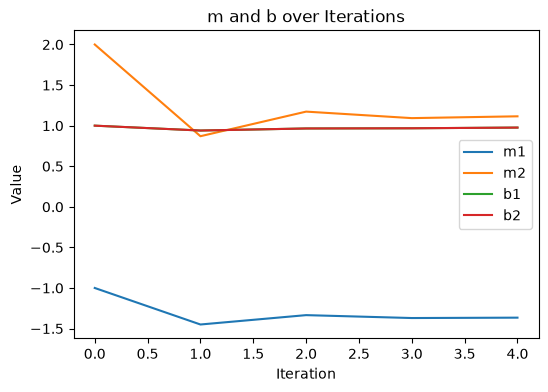

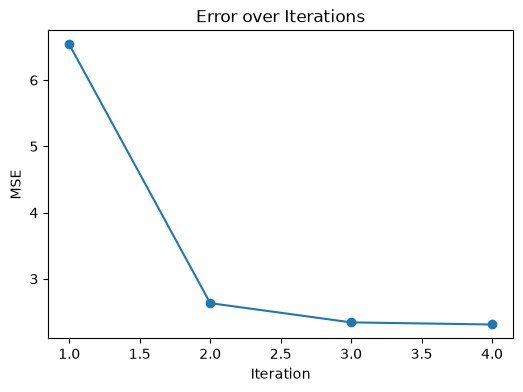

In [20]:
import matplotlib.pyplot as plt

m_history=np.array(m_history)
b_history=np.array(b_history)

plt.figure(figsize=(6,4))
plt.plot(m_history[:,0],label="m1")
plt.plot(m_history[:,1],label="m2")
plt.plot(b_history[:,0],label="b1")
plt.plot(b_history[:,1],label="b2")
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("m and b over Iterations")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(range(1,iterations+1),error_history,marker="o")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Error over Iterations")
plt.show()
